# Evaluacion del modelo de reconocimiento de entidades clinicas: metrica de similitud semantica

Como segunda metrica clasica, complementamos la coincidencia exacta con una version basada
en similitud semantica. La idea es simple: mantenemos exactamente las mismas predicciones
del modelo y la misma agregacion por documento, y lo unico que cambia es el criterio con el
que decidimos si una prediccion "acierta" o no. Asi, cualquier diferencia que aparezca entre
las dos metricas se explica solo por el criterio de comparacion, nunca por el modelo en si.

**Entrada:** resultados de la metrica de coincidencia exacta (predicciones del modelo por documento).
**Salida:** archivo de resultados que despues consume el harness de evaluacion integrado.

---
## Seccion 0 - Configuracion inicial

In [1]:
%pip install -q sentence-transformers
print("Listo.")

Listo.


In [2]:
import json
import re
import random
import itertools
from collections import Counter
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import torch
from scipy.optimize import linear_sum_assignment

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Seeds fijadas. Device:", device)

Seeds fijadas. Device: cpu


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
PROJECT_ROOT = Path("/content/drive/MyDrive/TopicosIA/Proyecto-Salud")

# Resultados de la metrica de coincidencia exacta, que se reutilizan como entrada.
DIM1_PATH  = PROJECT_ROOT / "M2" / "outputs" / "resultado_dimension1.json"

# Conjunto de referencia (gold set) con el texto clinico original de cada documento.
GOLD_SET_PATH = PROJECT_ROOT / "M2" / "eval_harness" / "gold_examples.jsonl"

OUTPUT_DIR = PROJECT_ROOT / "M2" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Resultados de coincidencia exacta:", DIM1_PATH, "| existe:", DIM1_PATH.exists())
print("Gold set                        :", GOLD_SET_PATH, "| existe:", GOLD_SET_PATH.exists())
print("Directorio de salida            :", OUTPUT_DIR)

Resultados de coincidencia exacta: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/resultado_dimension1.json | existe: True
Gold set                        : /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/eval_harness/gold_examples.jsonl | existe: True
Directorio de salida            : /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs


---
## Seccion 1 - Carga de las predicciones evaluadas

Se reutilizan directamente las predicciones ya generadas por la metrica de coincidencia
exacta, en lugar de volver a ejecutar el modelo. Esto garantiza que ambas metricas evaluan
exactamente el mismo conjunto de predicciones, de modo que cualquier diferencia entre sus
resultados se debe unicamente al criterio de comparacion utilizado, y no a variaciones en la
inferencia del modelo.

In [9]:
assert DIM1_PATH.exists(), (
    "No se encontro " + str(DIM1_PATH) + "\n"
    "Este notebook consume las predicciones generadas por la metrica de coincidencia "
    "exacta. Es necesario ejecutar ese notebook primero y guardar su archivo de "
    "resultados en la carpeta de salidas antes de continuar."
)

with open(DIM1_PATH, "r", encoding="utf-8") as f:
    dim1 = json.load(f)

true_by_doc    = {k: set(v) for k, v in dim1["true_by_doc"].items()}
pred_by_doc    = {k: set(v) for k, v in dim1["pred_by_doc"].items()}
metrics_exact  = dim1["metrics"]
casos_boundary = dim1.get("casos_boundary", [])

print("Predicciones cargadas")
print("  documentos      :", len(true_by_doc))
print("  entidades gold  :", sum(len(v) for v in true_by_doc.values()))
print("  entidades pred  :", sum(len(v) for v in pred_by_doc.values()))
print("  casos boundary  :", len(casos_boundary))
print()
print("  Coincidencia exacta (referencia):")
print("    P={:.4f}  R={:.4f}  F1={:.4f}  TP={}  FP={}  FN={}".format(
    metrics_exact["precision"], metrics_exact["recall"], metrics_exact["f1"],
    metrics_exact["tp"], metrics_exact["fp"], metrics_exact["fn"]))

Predicciones cargadas
  documentos      : 59
  entidades gold  : 757
  entidades pred  : 692
  casos boundary  : 510

  Coincidencia exacta (referencia):
    P=0.3584  R=0.3276  F1=0.3423  TP=248  FP=444  FN=509


In [10]:
# La funcion de coincidencia exacta se redefine aqui y se ejecuta nuevamente sobre los
# mismos conjuntos cargados, como verificacion de integridad de los datos.

def micro_prf1_by_doc(true_by_doc, pred_by_doc):
    tp = fp = fn = 0
    for doc_id in set(true_by_doc) | set(pred_by_doc):
        true_ents = true_by_doc.get(doc_id, set())
        pred_ents = pred_by_doc.get(doc_id, set())
        tp += len(true_ents & pred_ents)
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn}

metrics_exact = micro_prf1_by_doc(true_by_doc, pred_by_doc)
print("Coincidencia exacta recalculada (debe coincidir con la reportada originalmente):")
print(json.dumps(metrics_exact, indent=2))

Coincidencia exacta recalculada (debe coincidir con la reportada originalmente):
{
  "precision": 0.3583815028901734,
  "recall": 0.3276089828269485,
  "f1": 0.34230503795721184,
  "tp": 248,
  "fp": 444,
  "fn": 509
}


---
## Seccion 2 - Funciones de similitud consideradas

Implementamos tres funciones de similitud y corrimos la metrica completa con cada una, para
que la eleccion final se apoye en resultados concretos y no en una preferencia.

1. **Jaccard de palabras:** interseccion sobre union de los tokens de cada entidad. Es una
   medida lexica: captura solapamiento parcial de spans pero no reconoce sinonimos.
2. **Solapamiento de caracteres:** razon de subsecuencia comun mas larga entre las dos
   cadenas. Tambien lexica, pero tolera mejor variantes morfologicas y de puntuacion.
3. **Embeddings:** similitud coseno entre representaciones vectoriales generadas con
   `paraphrase-multilingual-MiniLM-L12-v2`. Es la unica funcion capaz de reconocer sinonimia
   sin solapamiento de superficie entre las cadenas.

In [11]:
from sentence_transformers import SentenceTransformer

EMB_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
st_model = SentenceTransformer(EMB_MODEL_NAME, device=device)

_emb_cache = {}

def _get_embeddings(texts):
    '''Genera embeddings normalizados, evitando recalcular strings ya procesados.'''
    nuevos = [t for t in dict.fromkeys(texts) if t not in _emb_cache]
    if nuevos:
        vecs = st_model.encode(nuevos, batch_size=64, show_progress_bar=False,
                               normalize_embeddings=True)
        for t, v in zip(nuevos, vecs):
            _emb_cache[t] = np.asarray(v, dtype=np.float32)
    return np.stack([_emb_cache[t] for t in texts])

print("Modelo de embeddings cargado:", EMB_MODEL_NAME)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo de embeddings cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [12]:
# Cada funcion recibe dos listas de entidades y devuelve la matriz de similitud
# (predicciones x entidades esperadas). Trabajar a nivel de matriz permite aplicar
# despues el algoritmo de asignacion bipartita de la Seccion 4.

def _tokens(s):
    return set(re.findall(r"\w+", s.lower()))

def sim_matrix_jaccard(preds, golds):
    TP = [_tokens(p) for p in preds]
    TG = [_tokens(g) for g in golds]
    M = np.zeros((len(preds), len(golds)), dtype=float)
    for i, tp in enumerate(TP):
        for j, tg in enumerate(TG):
            union = tp | tg
            M[i, j] = len(tp & tg) / len(union) if union else 0.0
    return M

def sim_matrix_chars(preds, golds):
    M = np.zeros((len(preds), len(golds)), dtype=float)
    for i, p in enumerate(preds):
        for j, g in enumerate(golds):
            M[i, j] = SequenceMatcher(None, p.lower(), g.lower()).ratio()
    return M

def sim_matrix_emb(preds, golds):
    P = _get_embeddings(list(preds))
    G = _get_embeddings(list(golds))
    return P @ G.T          # vectores normalizados -> el producto punto ES el coseno

SIM_FUNCS = {
    "jaccard": sim_matrix_jaccard,
    "chars":   sim_matrix_chars,
    "emb":     sim_matrix_emb,
}

def sim_par(a, b, nombre="emb"):
    '''Similitud de un solo par de cadenas, para inspeccion manual.'''
    return float(SIM_FUNCS[nombre]([a], [b])[0, 0])

print("Funciones de similitud disponibles:", list(SIM_FUNCS))

Funciones de similitud disponibles: ['jaccard', 'chars', 'emb']


### 2.1 - Evaluacion sobre casos representativos del corpus

Clinical BERT es un modelo de extraccion de spans (clasificacion por token), no un modelo
generativo: cada entidad que predice es una subcadena literal del documento clinico, al
igual que las entidades de referencia. Esto significa que el modelo no puede predecir un
sinonimo que no aparezca ya en el propio texto (por ejemplo, no puede escribir "sifilis" si
el documento dice "lues", salvo que el documento use ambos terminos en lugares distintos).
Por esta razon, la sinonimia lexica libre es poco frecuente en este corpus, mientras que los
errores de limite de span (boundary) y de formato o puntuacion son mucho mas comunes.

La siguiente tabla compara las tres funciones de similitud sobre casos reales extraidos de
las predicciones del modelo, y sobre dos casos sinteticos disenados para ilustrar el
comportamiento de la funcion elegida ante sinonimia y ante terminos clinicamente opuestos.

In [13]:
casos_demo = [
    ("boundary (limite de span)",
     "carcinoma verrugoso de", "carcinoma verrugoso de buscke-lowenstein"),
    ("boundary (limite de span)",
     "lesion", "lesion tumoral"),
    ("variante de puntuacion",
     "linfogranuloma venereo.", "linfogranuloma venereo"),
    ("solapamiento parcial",
     "lesion penoescrotal", "lesion tumoral"),
    ("span mas especifico",
     "adenopatias bilateral es iliacas e inguinales",
     "adenopatias bilaterales en las cadenas iliacas interna y externa y en las cadenas inguinales"),
    ("sintetico -- sigla vs. termino desarrollado",
     "iam", "infarto agudo de miocardio"),
    ("sintetico -- condiciones opuestas",
     "hipertension arterial", "hipotension arterial"),
    ("control -- entidades sin relacion",
     "adenopatias", "brucelosis"),
]

print(f"{'caso':<45}{'jaccard':>9}{'chars':>9}{'emb':>9}")
print("-" * 72)
for etiqueta, a, b in casos_demo:
    print(f"{etiqueta:<45}"
          f"{sim_par(a, b, 'jaccard'):>9.2f}"
          f"{sim_par(a, b, 'chars'):>9.2f}"
          f"{sim_par(a, b, 'emb'):>9.2f}")

caso                                           jaccard    chars      emb
------------------------------------------------------------------------
boundary (limite de span)                         0.60     0.71     0.91
boundary (limite de span)                         0.50     0.60     0.74
variante de puntuacion                            1.00     0.98     0.99
solapamiento parcial                              0.33     0.67     0.58
span mas especifico                               0.23     0.66     0.83
sintetico -- sigla vs. termino desarrollado       0.00     0.21     0.31
sintetico -- condiciones opuestas                 0.33     0.93     0.92
control -- entidades sin relacion                 0.00     0.38     0.43


**Interpretacion de la tabla:**

Boundary, variante de puntuacion, solapamiento parcial y span mas especifico son casos
reales, extraidos de las predicciones del modelo. Solo puntuacion lo resuelven las tres
funciones por igual (todas >0.98). En los demas, Jaccard se queda corto (0.50, 0.33, 0.23),
por debajo de nuestro umbral calibrado (~0.57); chars y embeddings si los resuelven, lo que
ya anticipa por que Jaccard queda descartado.

Los dos casos sinteticos muestran el margen y el riesgo de una funcion mas tolerante. La
sigla (IAM / infarto agudo de miocardio) recibe mas puntaje de embeddings (0.31), pero sigue
sin cruzar el umbral: ninguna funcion la reconoceria en la practica. El caso de
hipertension/hipotension es mas preocupante: chars (0.93) y embeddings (0.92) les dan
similitud muy alta a dos condiciones opuestas, mostrando que el riesgo no es exclusivo de los
embeddings sino de cualquier medida de superficie. Se detalla en la Seccion 7.

Elegimos **embeddings** como funcion oficial: su aporte principal es la tolerancia a
variantes de formato y limites de span parciales, el error dominante de este modelo. Las
otras dos quedan como analisis de sensibilidad en la Seccion 6.

---
## Seccion 3 - Calibracion del umbral de similitud

El umbral de decision es el parametro mas sensible de esta metrica: un cambio en su valor
altera el resultado sin que el modelo evaluado haya cambiado. Para evitar fijar un valor
arbitrario, se calibra usando dos distribuciones construidas a partir del propio corpus:

- **Casos positivos:** pares de entidades donde una es subcadena de la otra (errores de
  boundary detectados por la metrica de coincidencia exacta). Son casos en los que el modelo
  identifico correctamente la entidad, pero con un limite de span distinto al esperado.
  Representan exactamente el tipo de acierto que esta metrica busca reconocer.
- **Casos negativos:** pares formados por una entidad predicha en un documento y una entidad
  esperada de otro documento distinto, excluyendo coincidencias exactas. La gran mayoria
  corresponde a enfermedades sin relacion entre si.

El umbral se selecciona maximizando el indice de Youden (sensibilidad menos tasa de falsos
positivos) sobre estas dos distribuciones, lo que ofrece un mayor criterio. La Seccion 6 analiza como varia el resultado si se elige un umbral distinto.

In [14]:
SIM_OFICIAL = "emb"
sim_fn = SIM_FUNCS[SIM_OFICIAL]

# Casos positivos: pares boundary (subcadena), excluyendo coincidencias identicas.
pares_pos = [(c["predicho"], c["gold"]) for c in casos_boundary
             if c["predicho"] != c["gold"]]

# Casos negativos: entidades tomadas de documentos distintos.
doc_ids_orden = sorted(true_by_doc)
rng = random.Random(42)
pares_neg = []
for _ in range(4000):
    d1, d2 = rng.sample(doc_ids_orden, 2)
    p_pool = sorted(pred_by_doc.get(d1, set()))
    g_pool = sorted(true_by_doc.get(d2, set()))
    if not p_pool or not g_pool:
        continue
    a, b = rng.choice(p_pool), rng.choice(g_pool)
    if a != b:
        pares_neg.append((a, b))

pares_neg = list(dict.fromkeys(pares_neg))
print(f"Casos positivos (boundary)      : {len(pares_pos)}")
print(f"Casos negativos (cross-documento): {len(pares_neg)}")

Casos positivos (boundary)      : 510
Casos negativos (cross-documento): 3972


In [15]:
def sims_de_pares(pares, nombre):
    if not pares:
        return np.array([])
    A = [a for a, _ in pares]
    B = [b for _, b in pares]
    f = SIM_FUNCS[nombre]
    return np.array([f([a], [b])[0, 0] for a, b in zip(A, B)])

sims_pos = sims_de_pares(pares_pos, SIM_OFICIAL)
sims_neg = sims_de_pares(pares_neg, SIM_OFICIAL)

def resumen(nombre, v):
    print(f"{nombre:<12} n={len(v):>5}  media={v.mean():.3f}  p05={np.percentile(v,5):.3f}  "
          f"p50={np.percentile(v,50):.3f}  p95={np.percentile(v,95):.3f}  max={v.max():.3f}")

resumen("positivos", sims_pos)
resumen("negativos", sims_neg)

positivos    n=  510  media=0.853  p05=0.435  p50=0.941  p95=0.996  max=0.999
negativos    n= 3972  media=0.282  p05=0.066  p50=0.272  p95=0.537  max=0.989


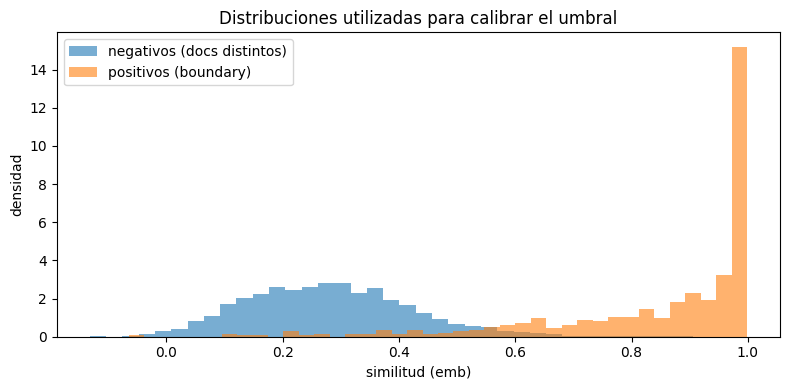

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(sims_neg, bins=40, alpha=0.6, density=True, label="negativos (docs distintos)")
plt.hist(sims_pos, bins=40, alpha=0.6, density=True, label="positivos (boundary)")
plt.xlabel(f"similitud ({SIM_OFICIAL})")
plt.ylabel("densidad")
plt.title("Distribuciones utilizadas para calibrar el umbral")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Umbral que maximiza el indice de Youden (sensibilidad - tasa de falsos positivos).
grid = np.round(np.arange(0.30, 0.991, 0.01), 3)
tabla_youden = []
for t in grid:
    tpr = float((sims_pos >= t).mean())
    fpr = float((sims_neg >= t).mean())
    tabla_youden.append((t, tpr, fpr, tpr - fpr))

t_opt, tpr_opt, fpr_opt, j_opt = max(tabla_youden, key=lambda r: r[3])
THRESHOLD = float(round(t_opt, 2))

print(f"Umbral calibrado: {THRESHOLD}")
print(f"  recupera el {tpr_opt:.1%} de los aciertos parciales (positivos)")
print(f"  acepta      el {fpr_opt:.1%} de los pares sin relacion (negativos)")
print(f"  indice de Youden = {j_opt:.3f}")
print()
print("Solapamiento entre las dos distribuciones en el umbral elegido:")
print(f"  positivos por debajo del umbral (aciertos parciales que se pierden): "
      f"{(sims_pos < THRESHOLD).mean():.1%}")
print(f"  negativos por encima del umbral (posible credito indebido)        : "
      f"{(sims_neg >= THRESHOLD).mean():.1%}")

Umbral calibrado: 0.57
  recupera el 90.8% de los aciertos parciales (positivos)
  acepta      el 3.4% de los pares sin relacion (negativos)
  indice de Youden = 0.874

Solapamiento entre las dos distribuciones en el umbral elegido:
  positivos por debajo del umbral (aciertos parciales que se pierden): 9.2%
  negativos por encima del umbral (posible credito indebido)        : 3.4%


---
## Seccion 4 - Algoritmo de asignacion

Contar con una matriz de similitud no es suficiente: es necesario decidir que prediccion se
empareja con que entidad esperada. Un ejemplo real del corpus ilustra por que esta decision
importa: la prediccion `"lesion"` tiene similitud alta con dos entidades esperadas distintas
del mismo documento (`"lesion tumoral"` y `"lesion penoescrotal"`). Si cada entidad esperada elige de forma independiente su mejor prediccion, esa
unica prediccion se contabilizaria como acierto tres veces, inflando artificialmente el
recall.

Por este motivo, la asignacion se restringe a una relacion **uno a uno**: cada prediccion se
empareja con, a lo sumo, una entidad esperada, y viceversa. Se implementan dos alternativas:

- **Greedy:** ordena todos los pares posibles por similitud descendente y va seleccionando el
  mejor par disponible mientras ninguno de sus dos elementos haya sido usado. Es simple y
  rapido, pero toma decisiones locales que pueden bloquear una combinacion mejor mas adelante.
- **Asignacion bipartita optima (algoritmo hungaro):** resuelve el problema de asignacion
  maximizando la similitud total del emparejamiento completo. Los pares por debajo del umbral
  se penalizan antes de resolver, para que el algoritmo los evite salvo que no exista
  alternativa, y luego se descartan del resultado final.

Se utiliza el algoritmo hungaro como metodo oficial, por tratarse de la solucion optima y no
de una heuristica, y el metodo greedy como control de sensibilidad en la Seccion 6.

In [18]:
PENALIZACION = -1e6   # costo muy alto para pares por debajo del umbral

def match_greedy(S, threshold):
    '''Empareja seleccionando siempre el mejor par disponible. Devuelve [(i, j, sim), ...].'''
    if S.size == 0:
        return []
    orden = np.dstack(np.unravel_index(np.argsort(-S, axis=None), S.shape))[0]
    usados_p, usados_g, pares = set(), set(), []
    for i, j in orden:
        i, j = int(i), int(j)
        if S[i, j] < threshold:
            break
        if i in usados_p or j in usados_g:
            continue
        pares.append((i, j, float(S[i, j])))
        usados_p.add(i)
        usados_g.add(j)
    return pares

def match_hungaro(S, threshold):
    '''Asignacion bipartita optima uno a uno que maximiza la similitud total.'''
    if S.size == 0:
        return []
    S_pen = np.where(S >= threshold, S, PENALIZACION)
    filas, cols = linear_sum_assignment(-S_pen)
    return [(int(i), int(j), float(S[i, j]))
            for i, j in zip(filas, cols) if S[i, j] >= threshold]

MATCHERS = {"greedy": match_greedy, "hungaro": match_hungaro}
MATCHER_OFICIAL = "hungaro"
print("Algoritmos de asignacion disponibles:", list(MATCHERS))

Algoritmos de asignacion disponibles: ['greedy', 'hungaro']


In [19]:
# Ilustracion del efecto de la restriccion uno a uno sobre un documento real.
doc_demo = "ex_0" if "ex_0" in true_by_doc else sorted(true_by_doc)[0]
preds_demo = sorted(pred_by_doc.get(doc_demo, set()))
golds_demo = sorted(true_by_doc.get(doc_demo, set()))
S_demo = sim_fn(preds_demo, golds_demo)

# Cuantas entidades esperadas tendrian a la misma prediccion como su mejor opcion.
mejor_pred_por_gold = S_demo.argmax(axis=0)
sim_mejor = S_demo.max(axis=0)
from collections import Counter
conteo = Counter(int(i) for i, s in zip(mejor_pred_por_gold, sim_mejor) if s >= THRESHOLD)
repetidas = {preds_demo[i]: c for i, c in conteo.items() if c > 1}

print(f"Documento {doc_demo}: {len(preds_demo)} predicciones, {len(golds_demo)} entidades esperadas")
print()
print("Predicciones que serian el mejor emparejamiento de mas de una entidad esperada")
print("(si no se aplicara la restriccion uno a uno):")
for p, c in sorted(repetidas.items(), key=lambda x: -x[1]):
    print(f"  {p!r} -> reclamaria {c} entidades esperadas")
print()
print(f"Sin restriccion uno a uno, aciertos en este documento = {int((sim_mejor >= THRESHOLD).sum())}")
print(f"Con asignacion hungara (uno a uno), aciertos = {len(match_hungaro(S_demo, THRESHOLD))}")

Documento ex_0: 12 predicciones, 28 entidades esperadas

Predicciones que serian el mejor emparejamiento de mas de una entidad esperada
(si no se aplicara la restriccion uno a uno):
  'carcinoma verrugoso de' -> reclamaria 6 entidades esperadas
  'lesión tumoral exofítica' -> reclamaria 3 entidades esperadas
  'lesión' -> reclamaria 2 entidades esperadas
  'lesión penoescrotal' -> reclamaria 2 entidades esperadas

Sin restriccion uno a uno, aciertos en este documento = 20
Con asignacion hungara (uno a uno), aciertos = 11


---
## Seccion 5 - Definicion de la metrica semantica

Con la funcion de similitud, el umbral y el algoritmo de asignacion ya definidos, el calculo
de verdaderos positivos, falsos positivos y falsos negativos se realiza por documento:

- **Verdadero positivo:** par emparejado con similitud igual o superior al umbral.
- **Falso positivo:** prediccion que no fue emparejada con ninguna entidad esperada.
- **Falso negativo:** entidad esperada que no fue emparejada con ninguna prediccion.

La agregacion es de tipo micro y por documento original, consistente con la metrica de
coincidencia exacta: se suman los verdaderos positivos, falsos positivos y falsos negativos
de todos los documentos, y solo al final se calculan precision, recall y F1.

Ademas del F1 estandar, se reporta un F1 ponderado por similitud (F1 soft), en el que cada
acierto contribuye segun su valor de similitud en lugar de contar como 1. Esta lectura
complementaria permite detectar si los emparejamientos aceptados estan, en promedio, cerca
del umbral o claramente por encima de el.

In [20]:
def strip_chunk_suffix(doc_id):
    return re.sub(r"_chunk\d+$", "", doc_id)

def semantic_prf1_by_doc(true_by_doc, pred_by_doc, sim_name=SIM_OFICIAL,
                         threshold=None, matcher_name=MATCHER_OFICIAL,
                         devolver_detalle=True):
    '''
    Variante semantica de la metrica de coincidencia exacta por documento.
    Agregacion micro por documento original, asignacion uno a uno con umbral.
    '''
    if threshold is None:
        threshold = THRESHOLD
    f = SIM_FUNCS[sim_name]
    matcher = MATCHERS[matcher_name]

    tp = fp = fn = 0
    soft_tp = 0.0
    detalle, no_emparejados = {}, {}

    for doc_id in sorted(set(true_by_doc) | set(pred_by_doc)):
        orig_id = strip_chunk_suffix(doc_id)
        golds = sorted(true_by_doc.get(doc_id, set()))
        preds = sorted(pred_by_doc.get(doc_id, set()))

        if not golds or not preds:
            fp += len(preds)
            fn += len(golds)
            if devolver_detalle:
                no_emparejados[orig_id] = {"fp": preds, "fn": golds}
            continue

        S = f(preds, golds)
        pares = matcher(S, threshold)

        tp += len(pares)
        fp += len(preds) - len(pares)
        fn += len(golds) - len(pares)
        soft_tp += sum(s for _, _, s in pares)

        if devolver_detalle:
            usados_p = {i for i, _, _ in pares}
            usados_g = {j for _, j, _ in pares}
            detalle[orig_id] = [
                {"pred": preds[i], "gold": golds[j], "sim": round(s, 4),
                 "exacto": preds[i] == golds[j]}
                for i, j, s in sorted(pares, key=lambda x: -x[2])
            ]
            no_emparejados[orig_id] = {
                "fp": [p for i, p in enumerate(preds) if i not in usados_p],
                "fn": [g for j, g in enumerate(golds) if j not in usados_g],
            }

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    soft_p  = soft_tp / (tp + fp) if (tp + fp) else 0.0
    soft_r  = soft_tp / (tp + fn) if (tp + fn) else 0.0
    soft_f1 = 2 * soft_p * soft_r / (soft_p + soft_r) if (soft_p + soft_r) else 0.0

    metrics = {"precision": precision, "recall": recall, "f1": f1,
               "tp": tp, "fp": fp, "fn": fn,
               "soft_precision": soft_p, "soft_recall": soft_r, "soft_f1": soft_f1,
               "similitud": sim_name, "umbral": threshold, "asignacion": matcher_name}
    return metrics, detalle, no_emparejados

print("Metrica definida.")

Metrica definida.


In [21]:
metrics_sem, detalle_sem, no_emparejados = semantic_prf1_by_doc(true_by_doc, pred_by_doc)

print("=== Metrica de similitud semantica ===")
print(f"  similitud : {metrics_sem['similitud']}  ({EMB_MODEL_NAME})")
print(f"  asignacion: {metrics_sem['asignacion']} (uno a uno)")
print(f"  umbral    : {metrics_sem['umbral']}")
print()
print(f"  Precision : {metrics_sem['precision']:.4f}")
print(f"  Recall    : {metrics_sem['recall']:.4f}")
print(f"  F1        : {metrics_sem['f1']:.4f}")
print(f"  TP={metrics_sem['tp']}  FP={metrics_sem['fp']}  FN={metrics_sem['fn']}")
print()
print(f"  F1 ponderado por similitud: {metrics_sem['soft_f1']:.4f}")

=== Metrica de similitud semantica ===
  similitud : emb  (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
  asignacion: hungaro (uno a uno)
  umbral    : 0.57

  Precision : 0.8714
  Recall    : 0.7966
  F1        : 0.8323
  TP=603  FP=89  FN=154

  F1 ponderado por similitud: 0.7914


In [22]:
# Comparacion directa entre la metrica de coincidencia exacta y la metrica semantica.
filas = [
    ("Precision", metrics_exact["precision"], metrics_sem["precision"]),
    ("Recall",    metrics_exact["recall"],    metrics_sem["recall"]),
    ("F1",        metrics_exact["f1"],        metrics_sem["f1"]),
]

print("=" * 62)
print(f"{'Metrica':<14}{'Coincid. exacta':>16}{'Similitud sem.':>16}{'Delta':>14}")
print("-" * 62)
for nombre, a, b in filas:
    print(f"{nombre:<14}{a:>16.4f}{b:>16.4f}{b - a:>+14.4f}")
print("-" * 62)
print(f"{'TP':<14}{metrics_exact['tp']:>16}{metrics_sem['tp']:>16}"
      f"{metrics_sem['tp'] - metrics_exact['tp']:>+14}")
print(f"{'FP':<14}{metrics_exact['fp']:>16}{metrics_sem['fp']:>16}"
      f"{metrics_sem['fp'] - metrics_exact['fp']:>+14}")
print(f"{'FN':<14}{metrics_exact['fn']:>16}{metrics_sem['fn']:>16}"
      f"{metrics_sem['fn'] - metrics_exact['fn']:>+14}")
print("=" * 62)
print()
print("Los verdaderos positivos adicionales corresponden a aciertos que la coincidencia")
print("exacta contaba como fallo total:")
print(f"  aciertos recuperados = {metrics_sem['tp'] - metrics_exact['tp']}")

Metrica        Coincid. exacta  Similitud sem.         Delta
--------------------------------------------------------------
Precision               0.3584          0.8714       +0.5130
Recall                  0.3276          0.7966       +0.4690
F1                      0.3423          0.8323       +0.4900
--------------------------------------------------------------
TP                         248             603          +355
FP                         444              89          -355
FN                         509             154          -355

Los verdaderos positivos adicionales corresponden a aciertos que la coincidencia
exacta contaba como fallo total:
  aciertos recuperados = 355


---
## Seccion 6 - Analisis de sensibilidad

En esta parte mostramos cuanto cambia el resultado final según las decisiones que tomamos: el umbral,
la funcion de similitud y el algoritmo de asignacion.

In [23]:
# 6.1 - Sensibilidad al umbral
umbrales = np.round(np.arange(0.40, 1.001, 0.05), 2)
curva = []
for t in umbrales:
    m, _, _ = semantic_prf1_by_doc(true_by_doc, pred_by_doc,
                                   threshold=float(t), devolver_detalle=False)
    curva.append((float(t), m["precision"], m["recall"], m["f1"], m["tp"]))

print(f"{'umbral':>7}{'P':>9}{'R':>9}{'F1':>9}{'TP':>7}")
print("-" * 41)
for t, p, r, f1, tp in curva:
    marca = "  <-- oficial" if abs(t - THRESHOLD) < 1e-9 else ""
    print(f"{t:>7.2f}{p:>9.4f}{r:>9.4f}{f1:>9.4f}{tp:>7}{marca}")

 umbral        P        R       F1     TP
-----------------------------------------
   0.40   0.9263   0.8468   0.8847    641
   0.45   0.9104   0.8322   0.8696    630
   0.50   0.8960   0.8190   0.8558    620
   0.55   0.8757   0.8005   0.8364    606
   0.60   0.8598   0.7860   0.8213    595
   0.65   0.8410   0.7688   0.8033    582
   0.70   0.8353   0.7635   0.7978    578
   0.75   0.8208   0.7503   0.7840    568
   0.80   0.8049   0.7358   0.7688    557
   0.85   0.7803   0.7133   0.7453    540
   0.90   0.7399   0.6764   0.7067    512
   0.95   0.6806   0.6222   0.6501    471
   1.00   0.2009   0.1836   0.1919    139


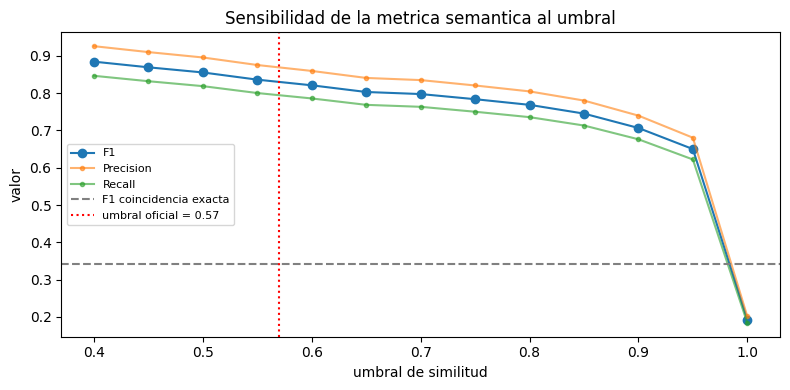

In [24]:
ts   = [c[0] for c in curva]
f1s  = [c[3] for c in curva]
ps   = [c[1] for c in curva]
rs   = [c[2] for c in curva]

plt.figure(figsize=(8, 4))
plt.plot(ts, f1s, marker="o", label="F1")
plt.plot(ts, ps, marker=".", alpha=0.6, label="Precision")
plt.plot(ts, rs, marker=".", alpha=0.6, label="Recall")
plt.axhline(metrics_exact["f1"], ls="--", color="gray", label="F1 coincidencia exacta")
plt.axvline(THRESHOLD, ls=":", color="red", label=f"umbral oficial = {THRESHOLD}")
plt.xlabel("umbral de similitud")
plt.ylabel("valor")
plt.title("Sensibilidad de la metrica semantica al umbral")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

En el ultimo punto de la grilla (umbral = 1.00) la cantidad de aciertos cae de golpe. Esto
no es un problema real de la metrica, sino un detalle tecnico: cuando comparamos un
embedding contra si mismo, la similitud casi nunca da exactamente 1.0 por errores minimos de
redondeo. Entonces, si exigimos una coincidencia perfecta (umbral = 1.00),
la metrica termina rechazando pares que en realidad son identicos. Este extremo no afecta
nuestro resultado oficial (umbral = 0.55); lo que hay que mirar es el rango de 0.40 a 0.95.

In [25]:
# 6.2 - Sensibilidad a la funcion de similitud y al algoritmo de asignacion
print(f"{'similitud':<12}{'asignacion':<12}{'P':>9}{'R':>9}{'F1':>9}{'TP':>7}")
print("-" * 58)
grid_resultados = {}
for sn in SIM_FUNCS:
    for mn in MATCHERS:
        m, _, _ = semantic_prf1_by_doc(true_by_doc, pred_by_doc, sim_name=sn,
                                       matcher_name=mn, devolver_detalle=False)
        grid_resultados[(sn, mn)] = m
        marca = "  <-- oficial" if (sn == SIM_OFICIAL and mn == MATCHER_OFICIAL) else ""
        print(f"{sn:<12}{mn:<12}{m['precision']:>9.4f}{m['recall']:>9.4f}"
              f"{m['f1']:>9.4f}{m['tp']:>7}{marca}")

similitud   asignacion          P        R       F1     TP
----------------------------------------------------------
jaccard     greedy         0.7442   0.6803   0.7108    515
jaccard     hungaro        0.7457   0.6816   0.7122    516
chars       greedy         0.8266   0.7556   0.7895    572
chars       hungaro        0.8309   0.7596   0.7937    575
emb         greedy         0.8613   0.7873   0.8226    596
emb         hungaro        0.8714   0.7966   0.8323    603  <-- oficial


---
## Seccion 7 - Alcance y limitaciones de la metrica

Esta seccion cuantifica que aporta la metrica semantica frente a la coincidencia exacta, y
que limitaciones introduce a cambio.

In [26]:
# 7.1 - Categorizacion de los aciertos adicionales frente a la coincidencia exacta
def normalizar(s):
    return re.sub(r"[^\w\s]", "", s.lower()).strip()

def categorizar(pred, gold):
    if pred == gold:
        return "exacto"
    if normalizar(pred) == normalizar(gold):
        return "variante de puntuacion/formato"
    if pred in gold or gold in pred:
        return "boundary (uno contiene al otro)"
    if _tokens(pred) & _tokens(gold):
        return "solapamiento parcial de palabras"
    return "sinonimo/parafrasis (sin solapamiento lexico)"

nuevos, por_categoria = [], Counter()
for doc_id, pares in detalle_sem.items():
    for par in pares:
        cat = categorizar(par["pred"], par["gold"])
        por_categoria[cat] += 1
        if not par["exacto"]:
            nuevos.append({"doc_id": doc_id, **par, "categoria": cat})

print(f"Total de aciertos (TP) de la metrica semantica: {metrics_sem['tp']}")
print(f"  de los cuales ya eran aciertos exactos      : {por_categoria['exacto']}")
print(f"  aciertos adicionales aportados por la similitud: {len(nuevos)}")
print()
print("Desglose de los aciertos por tipo de emparejamiento:")
for cat, n in por_categoria.most_common():
    print(f"  {cat:<48}{n:>5}  ({n / metrics_sem['tp']:.1%})")

Total de aciertos (TP) de la metrica semantica: 603
  de los cuales ya eran aciertos exactos      : 244
  aciertos adicionales aportados por la similitud: 359

Desglose de los aciertos por tipo de emparejamiento:
  exacto                                            244  (40.5%)
  variante de puntuacion/formato                    225  (37.3%)
  boundary (uno contiene al otro)                   105  (17.4%)
  solapamiento parcial de palabras                   15  (2.5%)
  sinonimo/parafrasis (sin solapamiento lexico)      14  (2.3%)


In [27]:
# Muestra de aciertos adicionales, ordenados de mayor a menor similitud
print("Ejemplos de aciertos que la coincidencia exacta contaba como fallo total:")
print()
for caso in sorted(nuevos, key=lambda c: -c["sim"])[:15]:
    print(f"  [{caso['doc_id']:<6}] sim={caso['sim']:.3f}  {caso['categoria']}")
    print(f"           pred: {caso['pred']!r}")
    print(f"           gold: {caso['gold']!r}")

Ejemplos de aciertos que la coincidencia exacta contaba como fallo total:

  [ex_27 ] sim=0.999  variante de puntuacion/formato
           pred: 'insuficiencia renal crónica secundaria a nefroangioesclerosis,'
           gold: 'insuficiencia renal crónica secundaria a nefroangioesclerosis'
  [ex_19 ] sim=0.999  variante de puntuacion/formato
           pred: 'hidrocefalia grave secundaria a hemorragia intraventricular,'
           gold: 'hidrocefalia grave secundaria a hemorragia intraventricular'
  [ex_29 ] sim=0.998  variante de puntuacion/formato
           pred: 'lesión de tres o más segmentos medulares (d1 a d6),'
           gold: 'lesión de tres o más segmentos medulares (d1 a d6)'
  [ex_32 ] sim=0.998  variante de puntuacion/formato
           pred: 'hemangioblastomas en protuberancia y médula espinal,'
           gold: 'hemangioblastomas en protuberancia y médula espinal'
  [ex_50 ] sim=0.998  variante de puntuacion/formato
           pred: 'eritema cutáneo en cuello, axilas, t

In [28]:
# 7.2 - Emparejamientos que dependen unicamente del embedding, sin ningun
# solapamiento lexico entre la prediccion y la entidad esperada.
sospechosos = [c for c in nuevos
               if c["categoria"] == "sinonimo/parafrasis (sin solapamiento lexico)"]

print(f"Emparejamientos que dependen unicamente del embedding: {len(sospechosos)} "
      f"({len(sospechosos) / max(metrics_sem['tp'], 1):.1%} del total de aciertos)")
print()
print("Requieren revision manual para determinar cuales son sinonimos reales:")
for caso in sorted(sospechosos, key=lambda c: -c["sim"])[:20]:
    print(f"  [{caso['doc_id']:<6}] sim={caso['sim']:.3f}  "
          f"pred={caso['pred']!r}  gold={caso['gold']!r}")

Emparejamientos que dependen unicamente del embedding: 14 (2.3% del total de aciertos)

Requieren revision manual para determinar cuales son sinonimos reales:
  [ex_8  ] sim=0.945  pred='desnutrición por'  gold='malnutrición'
  [ex_30 ] sim=0.748  pred='vvz'  gold='heces melénicas'
  [ex_35 ] sim=0.739  pred='neoformaciones.'  gold='vejiga de poca capacidad con neoformación'
  [ex_33 ] sim=0.663  pred='progresión tumoral'  gold='tumor estenosante de colon sigmoide'
  [ex_21 ] sim=0.651  pred='arritmias.'  gold='vía anómala'
  [ex_21 ] sim=0.649  pred='preexcitación'  gold='ritmo sinusal preexcitado'
  [ex_29 ] sim=0.642  pred='neuritis óptica,'  gold='visión borrosa de cerca'
  [ex_10 ] sim=0.617  pred='globo vesical,'  gold='letàlides'
  [ex_12 ] sim=0.613  pred='esclerosis y calcificación de toda la membrana peritoneal,'  gold='peritonitis'
  [ex_41 ] sim=0.611  pred='recidiva local sangrante'  gold='glande, que deformaba meato, con áreas ulceradas'
  [ex_23 ] sim=0.596  pred='(od)' 

In [29]:
# 7.3 - Ambiguedad dentro del propio conjunto de referencia: pares de entidades
# esperadas del mismo documento con similitud alta entre si.
pares_gold_ambiguos, total_pares_gold = 0, 0
ejemplos_ambiguos = []

for doc_id, golds in true_by_doc.items():
    golds = sorted(golds)
    if len(golds) < 2:
        continue
    S_gg = sim_fn(golds, golds)
    for i in range(len(golds)):
        for j in range(i + 1, len(golds)):
            total_pares_gold += 1
            if S_gg[i, j] >= THRESHOLD:
                pares_gold_ambiguos += 1
                ejemplos_ambiguos.append((doc_id, golds[i], golds[j], float(S_gg[i, j])))

frac_ambigua = pares_gold_ambiguos / total_pares_gold if total_pares_gold else 0.0
print(f"Pares de entidades esperadas del mismo documento con similitud >= umbral: "
      f"{pares_gold_ambiguos} / {total_pares_gold}  ({frac_ambigua:.2%})")
print()
print("Ejemplos de entidades esperadas mutuamente indistinguibles para esta metrica:")
for doc_id, a, b, s in sorted(ejemplos_ambiguos, key=lambda x: -x[3])[:12]:
    print(f"  [{doc_id:<6}] sim={s:.3f}  {a!r}  <->  {b!r}")

Pares de entidades esperadas del mismo documento con similitud >= umbral: 475 / 5434  (8.74%)

Ejemplos de entidades esperadas mutuamente indistinguibles para esta metrica:
  [ex_27 ] sim=0.990  'gammapatía monoclonal con igm'  <->  'gammapatía monoclonal igm'
  [ex_20 ] sim=0.990  'insuficiencia renal'  <->  'insuficiencia renal aguda'
  [ex_11 ] sim=0.974  'carcinoma de colon'  <->  'carcinoma de colon descendente'
  [ex_9  ] sim=0.973  'hepatitis aguda'  <->  'hepatitis isquémica'
  [ex_6  ] sim=0.971  'liposarcoma bien diferenciado'  <->  'liposarcoma desdiferenciado'
  [ex_45 ] sim=0.970  'pancreatitis aguda'  <->  'pancreatitis crónica'
  [ex_45 ] sim=0.960  'pancreatitis aguda'  <->  'pancreatitis aguda moderada-severa'
  [ex_6  ] sim=0.957  'liposarcoma bien diferenciado'  <->  'liposarcoma bien diferenciado (lipoma-like)'
  [ex_40 ] sim=0.944  'carcinoma de células acinares'  <->  'carcinoma de células acinares de bajo grado'
  [ex_1  ] sim=0.943  'hipertensión'  <->  'hiperte

In [30]:
# 7.4 - Prueba dirigida sobre pares clinicamente distintos que comparten un prefijo
# que invierte el significado.
sondas = [
    ("hipertension arterial", "hipotension arterial"),
    ("hiperglucemia", "hipoglucemia"),
    ("hipertiroidismo", "hipotiroidismo"),
    ("insuficiencia renal aguda", "insuficiencia renal cronica"),
    ("carcinoma de mama izquierda", "carcinoma de mama derecha"),
    ("ausencia de metastasis", "metastasis"),
]
print(f"Pares sinteticos clinicamente distintos y su similitud (umbral = {THRESHOLD}):")
print()
for a, b in sondas:
    s = sim_par(a, b, SIM_OFICIAL)
    veredicto = "se emparejarian" if s >= THRESHOLD else "se distinguen correctamente"
    print(f"  sim={s:.3f}  {a!r} vs {b!r}  ->  {veredicto}")

Pares sinteticos clinicamente distintos y su similitud (umbral = 0.57):

  sim=0.918  'hipertension arterial' vs 'hipotension arterial'  ->  se emparejarian
  sim=0.812  'hiperglucemia' vs 'hipoglucemia'  ->  se emparejarian
  sim=0.905  'hipertiroidismo' vs 'hipotiroidismo'  ->  se emparejarian
  sim=0.923  'insuficiencia renal aguda' vs 'insuficiencia renal cronica'  ->  se emparejarian
  sim=0.980  'carcinoma de mama izquierda' vs 'carcinoma de mama derecha'  ->  se emparejarian
  sim=0.797  'ausencia de metastasis' vs 'metastasis'  ->  se emparejarian


---
## Seccion 7.5 - Verificacion contra el texto clinico original

Los ejemplos citados en las secciones 7.2 y 7.3 se evaluaron comparando unicamente el texto
de cada entidad, sin ver la oracion completa del documento. Esto es suficiente para juzgar
errores de boundary o de formato, pero no para determinar si un par sin solapamiento lexico
es sinonimia real o un emparejamiento sin relacion. Para eso es necesario ver el contexto
clinico completo de cada mencion.

Dado que el modelo extrae spans literales del texto, tanto la prediccion como la entidad
esperada deben aparecer como subcadena (exacta o casi exacta) del documento original. Esta
seccion carga el texto completo de cada documento y muestra el contexto real alrededor de
las entidades citadas, para que la revision manual quede trazable a la fuente.

In [31]:
def cargar_textos_originales(path):
    '''Construye un diccionario doc_id -> texto clinico completo, en el mismo orden del gold set.'''
    textos = {}
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if line.strip():
                textos[f"ex_{i}"] = json.loads(line)["input"]
    return textos

assert GOLD_SET_PATH.exists(), (
    "No se encontro " + str(GOLD_SET_PATH) + ". Sin este archivo no es posible verificar "
    "los ejemplos contra el texto clinico original."
)
textos_originales = cargar_textos_originales(GOLD_SET_PATH)
print(f"Textos originales cargados: {len(textos_originales)} documentos")

Textos originales cargados: 59 documentos


In [32]:
def contexto(doc_id, entidad, ventana=70):
    '''
    Busca `entidad` como subcadena del texto original de `doc_id` (sin distincion de
    mayusculas, tolerando el punto o coma final que a veces agrega el proceso de
    segmentacion) y devuelve el fragmento de texto alrededor.
    '''
    texto = textos_originales.get(doc_id)
    if texto is None:
        return f"[documento {doc_id} no encontrado]"

    candidatos = [entidad, entidad.rstrip(".,;: ")]
    texto_low = texto.lower()
    for cand in candidatos:
        pos = texto_low.find(cand.lower())
        if pos != -1:
            ini = max(0, pos - ventana)
            fin = min(len(texto), pos + len(cand) + ventana)
            return "..." + texto[ini:fin].replace("\n", " ") + "..."
    return "[no encontrado como subcadena literal]"

print("Funcion de verificacion lista.")

Funcion de verificacion lista.


In [33]:
# Verificacion en contexto de los pares de la Seccion 7.2
print("=" * 90)
print("VERIFICACION EN CONTEXTO -- emparejamientos que dependen unicamente del embedding")
print("=" * 90)
for c in sorted(sospechosos, key=lambda x: -x["sim"]):
    print(f"\n[{c['doc_id']}] sim={c['sim']:.3f}")
    print(f"  PRED  {c['pred']!r}")
    print(f"    contexto: {contexto(c['doc_id'], c['pred'])}")
    print(f"  GOLD  {c['gold']!r}")
    print(f"    contexto: {contexto(c['doc_id'], c['gold'])}")

VERIFICACION EN CONTEXTO -- emparejamientos que dependen unicamente del embedding

[ex_8] sim=0.945
  PRED  'desnutrición por'
    contexto: ...s meses antes, había ingresado por cuadro de anasarca en relación con desnutrición por síndrome malabsortivo, y en ese momento se inició la administración d...
  GOLD  'malnutrición'
    contexto: ...precisar cirugía por obstrucción intestinal. Secundariamente presenta malnutrición con hipoalbuminemia grave, anemia de trastornos crónicos severa, úlce...

[ex_30] sim=0.748
  PRED  'vvz'
    contexto: ...ta a su médico de atención primaria, que instaura tratamiento para el VVZ con brivudina (Nervinex® comprimidos de 125 mg) 1 comprimido/24 h v.o...
  GOLD  'heces melénicas'
    contexto: ..., acude a urgencias con un cuadro de dolor abdominal con expulsión de heces melénicas, dolor en cavidad oral y disfagia. A su llegada a urgencias está afeb...

[ex_35] sim=0.739
  PRED  'neoformaciones.'
    contexto: ...nsulta de urología periódicamente para 

In [34]:
# Verificacion en contexto de los pares gold-gold citados en la Seccion 7.3
pares_citados = [
    ("ex_45", "pancreatitis aguda", "pancreatitis crónica"),
    ("ex_6",  "liposarcoma bien diferenciado", "liposarcoma desdiferenciado"),
    ("ex_9",  "hepatitis aguda", "hepatitis isquémica"),
]
print("VERIFICACION EN CONTEXTO -- pares de entidades esperadas citados en la Seccion 7.3")
for doc_id, a, b in pares_citados:
    print(f"\n[{doc_id}]")
    print(f"  {a!r}")
    print(f"    contexto: {contexto(doc_id, a)}")
    print(f"  {b!r}")
    print(f"    contexto: {contexto(doc_id, b)}")

VERIFICACION EN CONTEXTO -- pares de entidades esperadas citados en la Seccion 7.3

[ex_45]
  'pancreatitis aguda'
    contexto: ...Varón de 54 años con episodios de pancreatitis aguda de repetición, que como antecedentes personales presenta hiperlipemia...
  'pancreatitis crónica'
    contexto: ...s complementarias una colangiorresonancia magnética donde aparece una pancreatitis crónica sobre páncreas divisum y una atrofia del parénquima hepático, y una E...

[ex_6]
  'liposarcoma bien diferenciado'
    contexto: ...as células pleomórficas bizarras constituyendo un cuadro dominante de liposarcoma bien diferenciado, observandose lobulaciones de tejido de aspecto cartilaginoso, el cua...
  'liposarcoma desdiferenciado'
    contexto: ...mponente condrosarcoma grado II y III. La tumoración corresponde a un liposarcoma desdiferenciado en donde el componente adiposo es clásico tipo liposarcoma bien difer...

[ex_9]
  'hepatitis aguda'
    contexto: ... presentando una importante elevación d

---
## Conclusiones

**Que mide esta metrica.** Evalua si el modelo identifico la entidad clinica correcta, sin
importar si acerto el limite exacto del span. Para cada documento comparamos las entidades
predichas y esperadas por similitud coseno de embeddings, resolvemos una asignacion uno a uno
(algoritmo hungaro) y contamos como acierto los pares con similitud >= 0.57 (umbral
calibrado). Lo que queda sin pareja cuenta como falso positivo o falso negativo, agregado por
documento.

**Que aporta frente a la coincidencia exacta.** La coincidencia exacta da F1 = 0.3423
(precision 0.3584, recall 0.3276); la semantica da F1 = 0.8323 (precision 0.8714, recall
0.7966), sobre las mismas predicciones. La diferencia viene de 359 aciertos que la
coincidencia exacta descarta por completo y la semantica recupera: variantes de puntuacion
(225, 62.7%), errores de limite de span (105, 29.2%), solapamiento parcial (15, 4.2%) y
sinonimia sin solapamiento lexico (14, 3.9%). Esta ultima categoria es chica porque Clinical
BERT extrae spans literales del texto y no puede generar un sinonimo que el documento no
contenga ya -- el aporte real de los embeddings aca es tolerancia a formato y boundary, mas
que reconocimiento de sinonimia libre.

De esos 14 emparejamientos "solo embedding", la revision manual encontro dos sinonimos
genuinos ("desnutricion por"/"malnutricion" y "preexcitacion"/"ritmo sinusal preexcitado") y
el resto sin relacion clinica real. Es una fraccion minima del total (14/603) que no cambia
el resultado, pero confirma con casos concretos que el umbral admite algo de ruido.

**Limitaciones de la metrica semantica.**

1. *El umbral es una decision calibrada, no un valor natural del problema.* Con 0.57 se
   pierde el 9.2% de los aciertos parciales y se acepta el 3.4% de pares sin relacion. El F1
   varia entre 0.885 (umbral 0.40) y 0.650 (umbral 0.95): 23 puntos de diferencia segun donde
   se corte.

2. *Puede sobreestimar cuando dos entidades del mismo documento son semanticamente cercanas
   entre si.* El 8.7% de los pares de entidades esperadas del mismo documento superan el
   umbral entre ellas. En varios casos no son opuestos clinicos sino fases de una misma
   condicion (pancreatitis aguda que progresa a cronica, liposarcoma con componentes
   diferenciado y desdiferenciado, hepatitis aguda de causa isquemica). La restriccion uno a
   uno evita el doble cobro, pero no evita que una prediccion se empareje con la entidad
   equivocada y cuente como acierto igual, perdiendo el matiz que el conjunto de referencia
   buscaba distinguir.

3. *El modelo de embeddings es de proposito general, no clinico.* Pares opuestos por un solo
   prefijo (hipertension/hipotension, hiperglucemia/hipoglucemia) reciben similitud alta, un
   riesgo que un embedding entrenado en dominio biomedico probablemente reduciria.

Ademas, la metrica hereda dos limitaciones del planteamiento general: trabaja sobre texto y
no sobre posiciones, asi que una entidad correcta en el lugar equivocado del documento cuenta
como acierto; y parte de los documentos exceden la longitud maxima del modelo, por lo que
algunos falsos negativos son truncamiento de entrada y no error de extraccion.

---
## Seccion 8 - Exportacion de resultados

In [35]:
resultado_dimension1b = {
    "dimension": "metrica_clasica_matching_semantico",
    "modelo": "PlanTL-GOB-ES/roberta-base-biomedical-clinical-es",
    "predicciones_origen": str(DIM1_PATH),
    "gold_set": str(GOLD_SET_PATH),
    "n_ejemplos_evaluados": len(true_by_doc),

    "configuracion": {
        "modelo_embeddings": EMB_MODEL_NAME,
        "funcion_similitud": SIM_OFICIAL,
        "algoritmo_asignacion": MATCHER_OFICIAL,
        "restriccion": "uno a uno",
        "umbral": THRESHOLD,
        "criterio_umbral": "indice de Youden sobre positivos boundary vs negativos cross-document",
        "umbral_tpr_positivos": round(float((sims_pos >= THRESHOLD).mean()), 4),
        "umbral_fpr_negativos": round(float((sims_neg >= THRESHOLD).mean()), 4),
    },

    "metrics": {k: v for k, v in metrics_sem.items()},
    "metrics_exact_match_referencia": metrics_exact,

    "sensibilidad_umbral": [
        {"umbral": t, "precision": p, "recall": r, "f1": f1, "tp": tp}
        for t, p, r, f1, tp in curva
    ],
    "sensibilidad_configuracion": [
        {"similitud": sn, "asignacion": mn,
         "precision": m["precision"], "recall": m["recall"], "f1": m["f1"], "tp": m["tp"]}
        for (sn, mn), m in grid_resultados.items()
    ],

    "aciertos_por_categoria": dict(por_categoria),
    "aciertos_nuevos": nuevos,
    "emparejamientos_solo_embedding": sospechosos,
    "ambiguedad_gold": {
        "pares_ambiguos": pares_gold_ambiguos,
        "pares_totales": total_pares_gold,
        "fraccion": round(frac_ambigua, 4),
        "ejemplos": [{"doc_id": d, "gold_a": a, "gold_b": b, "sim": round(s, 4)}
                     for d, a, b, s in sorted(ejemplos_ambiguos, key=lambda x: -x[3])[:50]],
    },
    "detalle_emparejamientos": detalle_sem,
    "no_emparejados": no_emparejados,
}

output_path = OUTPUT_DIR / "resultado_dimension1b_similitud.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(resultado_dimension1b, f, indent=2, ensure_ascii=False)

print("Guardado en:", output_path)
print()
print("Resumen final:")
print(f"  Coincidencia exacta : F1 = {metrics_exact['f1']:.4f}")
print(f"  Similitud semantica : F1 = {metrics_sem['f1']:.4f}  "
      f"(umbral={THRESHOLD}, {SIM_OFICIAL}, {MATCHER_OFICIAL} uno a uno)")
print(f"  Aciertos recuperados: {metrics_sem['tp'] - metrics_exact['tp']}")

Guardado en: /content/drive/MyDrive/TopicosIA/Proyecto-Salud/M2/outputs/resultado_dimension1b_similitud.json

Resumen final:
  Coincidencia exacta : F1 = 0.3423
  Similitud semantica : F1 = 0.8323  (umbral=0.57, emb, hungaro uno a uno)
  Aciertos recuperados: 355


---
### Integracion con el harness de evaluacion

El archivo de resultados de este notebook se guarda en la carpeta de salidas compartida del
proyecto y sigue esta estructura:

```json
{
  "configuracion": {"funcion_similitud": str, "algoritmo_asignacion": str, "umbral": float, ...},
  "metrics": {"precision": float, "recall": float, "f1": float,
              "tp": int, "fp": int, "fn": int, "soft_f1": float},
  "metrics_exact_match_referencia": {...},
  "sensibilidad_umbral": [{"umbral": float, "f1": float, ...}, ...],
  "aciertos_por_categoria": {...},
  "detalle_emparejamientos": {"ex_0": [{"pred": str, "gold": str, "sim": float}, ...], ...}
}
```
